# COAPS Daily Swath — Plot Types and Arguments

This notebook contains the plotting functions from `modern_map_swath_data.py`
**inline** (no `import modern_map_swath_data`).

The only external project import is `read` from `read_netCDF.py`.

**Plot types** (set `plot_type=` to one of):
- `"vectors"` — wind vectors (`quiver`)
- `"barbs"` — wind barbs
- `"speed"` — wind speed scatter
- `"flags"` — quality flags
- `"param"` — any other netCDF variable


## 1. Imports


In [91]:
import os
import copy
import math
import numpy as np
import cartopy
import matplotlib
matplotlib.use("Agg")
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cartopy.mpl.ticker as cticker
from IPython.display import Image, display

# Only dependency outside this notebook: the netCDF reader
from read_netCDF import read


## 2. Plotting functions (from `modern_map_swath_data.py`)

These are the same helpers the CLI script uses: map setup, colorbars,
`plot_vectors` / `plot_barbs` / `plot_points`, `generate_plot`, and `read_file`.


In [92]:
DEFAULT_CMAP = plt.cm.jet
DEFAULT_OVER_COLOR = 'darkorchid'
DEFAULT_UNDER_COLOR = 'white'

def world_map(lon_0, bound_box, resolution='50m'):
    fig = plt.figure()
    
    #Draw map according to bound_box if it exists
    if bound_box.count(None) == len(bound_box):
        #no bound box
        ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=lon_0))
        ax.set_global()
    else:
        #create map around lon_0 and set bound box extent
        ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=lon_0))
        
        ax.set_extent([bound_box[0], bound_box[1], bound_box[2],
                       bound_box[3]], crs=ccrs.PlateCarree())
    
    
    ax.coastlines(resolution=resolution, color='black', linewidth=0.2)
    land = cartopy.feature.NaturalEarthFeature('physical', 'land', resolution,
                                               edgecolor='k',
                                               facecolor='lightgrey',
                                               linewidth=0)
    ocean = cartopy.feature.NaturalEarthFeature('physical', 'ocean',
                                                resolution, edgecolor='k',
                                                facecolor='black', linewidth=0)
    lakes = cartopy.feature.NaturalEarthFeature('physical', 'lakes',
                                                resolution, edgecolor='k',
                                                facecolor='black', linewidth=0)
    ax.add_feature(land, zorder=0)
    ax.add_feature(ocean, zorder=0)
    ax.add_feature(lakes, zorder=0)
    
    cart_map = draw_gridlines(ax, lon_0, bound_box)
    
    return cart_map, fig

def get_yticks(bound_box):
    '''Function to get the y gridlines on zoomed plots, based on bound_box'''
    south_lim = bound_box[2]
    north_lim = bound_box[3]
    
    #Get the range of latitude values
    y_range = north_lim - south_lim
    #Custom function to find an acceptable amount of gridlines based on the
    #   latitude range
    y_distribution = round((0.075 * (y_range) + 5.5))
    
    #Functions to determine evenly spaced ticks that fit into our range
    minimum = y_range / y_distribution
    magnitude = 10 ** math.floor(math.log(minimum, 10))
    residual = minimum / magnitude
    if residual > 7:
        tick = 10 * magnitude
    elif residual > 5:
        tick = 5 * magnitude
    elif residual > 4:
        tick = 4 * magnitude
    elif residual > 3:
        tick = 3 * magnitude
    elif residual > 2:
        tick = 2 * magnitude
    else:
        tick = magnitude
    
    #Create yticks based on incrementing the append_val by the tick length
    append_val = south_lim
    yticks = [append_val]
    while (append_val + tick) < north_lim:
        append_val += tick
        yticks.append(append_val)
    yticks.append(north_lim)
    
    return yticks
    
def get_xticks(bound_box):
    '''Function to get the y gridlines on zoomed plots, based on bound_box'''
    west_lim = bound_box[0]
    east_lim = bound_box[1]
    
    #Get the range of longitude values
    x_range = east_lim - west_lim
    #Custom function to find an acceptable amount of gridlines based on the
    #   longitude range
    x_distribution = round((0.0353 * (x_range) + 6.2941))
    
    #Functions to determine evenly spaced ticks that fit into our range
    minimum = x_range / x_distribution
    magnitude = 10 ** math.floor(math.log(minimum, 10))
    residual = minimum / magnitude
    if residual > 7:
        tick = 10 * magnitude
    elif residual > 5:
        tick = 8 * magnitude
    elif residual > 4:
        tick = 5 * magnitude
    elif residual > 2:
        tick = 4 * magnitude
    elif residual > 1:
        tick = 2 * magnitude
    else:   
        tick = magnitude
    
    #Create xticks based on incrementing the append_val by the tick length
    append_val = west_lim
    xticks = [append_val]
    while (append_val + tick) < east_lim:
        append_val += tick
        xticks.append(append_val)
    xticks.append(east_lim)
    
    return xticks

def draw_gridlines(ax, lon_0, bound_box):
    ''' Draw gridlines and ticks on the map'''

    if bound_box.count(None) == len(bound_box):
        #no zoom
        yticks = np.arange(-90, 100, 10)
        
        if lon_0 == 0:
            xticks = np.arange(-180, 200, 20)
        else:
            right_limit = (180 + lon_0)
            left_limit = (-180 + lon_0)
            xticks = np.arange(left_limit, right_limit, 20)
            for ind, val in enumerate(xticks):
                if val > 180:
                    xticks[ind] = val - 360
                if val < -180:
                    xticks[ind] = val + 360
    else:
        #Zoomed plot
        #Call custom functions to determine gridlines based on
        # the size of the bounding box
        yticks = get_yticks(bound_box)
        xticks = get_xticks(bound_box)


    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    
    ax.set_xticklabels(xticks, fontsize=5, fontstretch='condensed')
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    ax.set_yticklabels(yticks, fontsize=5)
    ax.yaxis.tick_left()

    lon_formatter = cticker.LongitudeFormatter()
    lat_formatter = cticker.LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    ax.grid(linewidth=.5, color='white', alpha=0.7, linestyle='dotted')
    
    return ax

def lon_plusminus_east(lon, lon_0):
    '''
     Ensures longitude values are in a valid range for plotting.
        for matplotlib to plot points correctly, lon values have to be within
        the range lon_0 - 180 to lon_0 +180. lon_0 refers to the longitude
        value in the middle of the desired map. usually 0, but but you can use
        -160 as to not break up the pacific ocean if desired.
    '''
    if lon > lon_0 + 180:
        return lon - 360.0
    return lon

def adjust_lon(lon, lon_0):
    '''Shifts center of plot based on option lon_0 argument'''
    list_lon_0 = [lon_0] * len(lon[0])
    for i, along_track in enumerate(lon):
        #apply (along_track - list_lon_0) at every index
        lon[i] = list(map(lambda x, y: x - y, along_track, list_lon_0))

    return lon

def configure_colors(data, vmin=None, vmax=None, num_colors=10,
                     plot_type=None, data_units='m/s', colors=DEFAULT_CMAP,
                     over_color=DEFAULT_OVER_COLOR,
                     under_color=DEFAULT_UNDER_COLOR):
    '''
    Create parameters needed to configure the colorbar. A colormap is selected
    and colors are normalized based on data values
    or user supplied min and max.
    data: A list of data values over which to normalize the colorbar.
    vmin: The minimum value of the colorbar. Optional.
    vmax: The maximum value of the colorbar. Optional.
    '''

    min_data = data.min(axis=0).min()
    max_data = data.max(axis=0).max()
    
    if plot_type == "barbs" or plot_type == "vectors" or plot_type == "speed":
        #If data is in m/s, convert vmin/vmax assumed in knots to m/s
        if plot_type == "barbs" and data_units == 'm/s':
            if vmin is None: vmin = 0
            else: vmin = vmin * .51444
        
            if vmax is None: vmax = max_data
            else: vmax = vmax * .51444
        else:
            if vmin is None: vmin = 0 
            if vmax is None: vmax = max_data
    else:
        if vmin is None: vmin = min_data
        if vmax is None: vmax = max_data
        
    colorslist = [colors(i) for i in range(colors.N)]
    
    bounds = discrete_cmap_bounds(vmax, vmin, num_colors)
    cm = LinearSegmentedColormap.from_list('cmap', colorslist, N=num_colors)
    
    # If data is outside of colorbar limits, add triangles filled with special
    # color to indicate out-of-bounds data on the colorbar
    if min_data < vmin and vmax < max_data:
        extend = 'both'
        cm.set_over(over_color) # top triangle color
        cm.set_under(under_color) # bottom triangle color
    elif min_data < vmin:
        extend = 'min'
        cm.set_under(under_color) # bottom triangle color
    elif vmax < max_data:
        extend = 'max'
        cm.set_over(over_color) # top triangle color
    else:
        extend = 'neither'
    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = matplotlib.cm.ScalarMappable(cmap=cm, norm=norm)
    sm.set_array([])
    return norm, cm, sm, extend, bounds

def discrete_cmap_bounds(max_val, min_val, num_ticks=10):
    '''
    This function creates the bounds for a discrete colorbar. Nothing fancy
    on the colorbar, just the bare minimum of a discrete colorbar with evenly
    spaced ticks
    '''
    bounds = []
    bounds.append(min_val)
 
    incrm_val = (max_val-min_val) / num_ticks

    append_val = min_val
    for x in range(1, num_ticks + 1):
        append_val += incrm_val
        bounds.append(append_val)
    return bounds

def apply_colorbar(sm, extend, plot_type, bounds, cart_map,
                   fig, data_units='m/s'):
    '''
    Apply the colorbar to the plot, making it the same height as the plot
    and adjust the font size of the labels. This function must be called
    after data has been plotted with a call to matplotlib.pyplot.
    extend: 'neither', 'box', 'min', or 'max' to indicate which end of the
    colorbar should contain a triangle.
    '''
    # Size the colorbar to be the same height as the plot.
    # Create an axes on the right side of ax. The width of cax will be 3.5%
    # of ax and the padding between cax and ax will be fixed at 0.05 inch.
    divider = make_axes_locatable(cart_map)
    ax_cb = divider.new_horizontal(size="5%", pad=0.1, axes_class=plt.Axes)
    fig.add_axes(ax_cb)
 
    cbar = plt.colorbar(sm, cax=ax_cb, extend=extend)
    if plot_type == 'barbs' and data_units == "m/s":
        #In knots
        tick = bounds
        cbar.set_ticks(tick)
         #Ticks are still in (m/s), but labeled in knots
        tick = [round(x*1.94384, 2) for x in tick]
        cbar.set_ticklabels(tick)
    else:
        #ticks are in m/s according to bounds given
        cbar.set_ticks(bounds)
    # Set font for colorbar labels
    cbar.ax.tick_params(labelsize=6)

def plot_vectors(x, y, u, v, speed, vmin, vmax, filename, imgname,
                 cart_map, fig, title, vector_scale=None):
    '''Plot vectors on the map using quiver()'''
    
    norm, cm, sm, extend, bounds = configure_colors(speed, vmin=vmin,
                                                    vmax=vmax,
                                                    plot_type="vectors")

    p = cart_map.quiver(x, y, u, v, speed, cmap=cm, norm=norm,
                        scale=vector_scale,
                        pivot='middle')

    key_num = 20
    cart_map.quiverkey(p, 1.05, -.06, key_num, '%s m/s' % key_num,
                       labelpos='E', labelsep=.05, coordinates='axes',
                       fontproperties=dict(size=7, weight='bold'))
    plt.title(title, fontsize=12)
    apply_colorbar(sm, extend, "vectors", bounds, cart_map, fig)

    
    plt.savefig(imgname, dpi=300, bbox_inches='tight', pad_inches=0.2)
    print(imgname + " created")
    
def plot_barbs(x, y, u, v, speed, vmin, vmax, filename, imgname,
               cart_map, fig, barb_length, data_units, title):
    '''Plot barbs on map'''
    norm, cm, sm, extend, bounds = configure_colors(speed, vmin=vmin,
                                                    vmax=vmax,
                                                    plot_type="barbs",
                                                    data_units=data_units)
    if data_units == 'm/s':
        barb_inc = (2.57222, 5.144, 25.722)
    else:   #units are defaulted to knots
        barb_inc = (5, 10, 50)
    
    #Create separate arrays, one for south of equator and one for
    # north of equator
    mask = (y < 0)
    mask_invert = (y >= 0)
    
    x_flip = np.ma.array(x, mask=mask_invert)
    x = np.ma.array(x, mask=mask)
    y_flip = np.ma.array(y, mask=mask_invert)
    y = np.ma.array(y, mask=mask)
    u_flip = np.ma.array(u, mask=mask_invert)
    u = np.ma.array(u, mask=mask)
    v_flip = np.ma.array(v, mask=mask_invert)
    v = np.ma.array(v, mask=mask)
    speed_flip = np.ma.array(speed, mask=mask_invert)
    speed = np.ma.array(speed, mask=mask)
            
    #Plot barbs. barb_increments are based on knot - m/s conversion
    #Two calls to barbs(), one for values above the equator and one for barbs
    #   north of equator due to convention that barbs are flipped depending
    #   on which hemisphere they live
    p = cart_map.barbs(x, y, u, v, speed, length=barb_length, linewidth=0.16,
                       barb_increments=dict(half=barb_inc[0],
                                            full=barb_inc[1],
                                            flag=barb_inc[2]),
                       cmap=cm, norm=norm, flip_barb=False,
                       sizes=dict(emptybarb=0.25, spacing=0.25, height=0.45))
    p_invert = cart_map.barbs(x_flip, y_flip, u_flip, v_flip, speed_flip,
                              length=barb_length, linewidth=0.16,
                              barb_increments=dict(half=barb_inc[0],
                                                   full=barb_inc[1],
                                                   flag=barb_inc[2]),
                              cmap=cm, norm=norm, flip_barb=True,
                              sizes=dict(emptybarb=0.25, spacing=0.25,
                                         height=0.45))
    plt.title(title, fontsize=12)
    apply_colorbar(sm, extend, "barbs", bounds, cart_map,
                   fig, data_units=data_units)
    plt.savefig(imgname, dpi=250, bbox_inches='tight', pad_inches=0.2)
    print(imgname + " created")
    
def plot_points(x, y, param, vmin, vmax, filename, imgname,
                cart_map, fig, title, point_size, plot_type):
    '''Plot speed points or quality flag'''
    
    if plot_type == 'flags':
        norm, cm, sm, extend, bounds = configure_colors(param, vmin=0,
                                                        vmax=1,
                                                        num_colors=2,
                                                        plot_type=plot_type)
        #Plot the points
        plt.scatter(x, y, c=param, cmap=cm, norm=norm, s=point_size)
        
        #Get min and max colors of default color map (red and blue for jet)
        colors = DEFAULT_CMAP
        colorslist = [colors(i) for i in range(colors.N)]
        #Create two empty scatterplots, set labels accordingly, for legend
        plt.scatter([None], [None], c=colorslist[-1],
                    s=point_size, label="Invalid Data")
        plt.scatter([None], [None], c=colorslist[0],
                    s=point_size, label="Valid Data")
        #Add legend to the plot
        plt.legend(fontsize='5', markerscale=4, facecolor='lightgrey',
                   edgecolor='black', loc=2, bbox_to_anchor=(.9, .05),
                   fancybox=0, borderaxespad=0., handletextpad=.2,
                   borderpad=.6, labelspacing=1.2)
        plt.title(title, fontsize=12)
    else:
        norm, cm, sm, extend, bounds = configure_colors(param, vmin=vmin,
                                                        vmax=vmax,
                                                        num_colors=10,
                                                        plot_type=plot_type)
        plt.scatter(x, y, c=param, cmap=cm, norm=norm, s=point_size)
        #Must call plt.title before apply colorbar
        plt.title(title, fontsize=12)
        apply_colorbar(sm, extend, 'points', bounds, cart_map, fig)

    # Replace the extension right before saving
    if imgname.endswith('.jpg'):
        imgname = imgname[:-4] + '.png'
    elif imgname.endswith('.jpeg'):
        imgname = imgname[:-5] + '.png'

    plt.savefig(imgname, dpi=300, bbox_inches='tight', pad_inches=0.2)
    print(imgname + " created")
    
def scale(bound_box, plot_num_points, plot_type, barb_size,
          cross_track, vector_size=None):
    '''
    A custom scaling function created to set default n values,
    size of barbs, and size of vectors
    '''   
 
    #Linear scale based on size of swaths/density of data.
    #adds this value to the final n. The larger the cross track of the
    #swaths are, the more we subset our data so it is not too dense
    add_n = round((cross_track*0.0918) - 2.3895)
    #ensure add_n is always at least 1 and never 0 or worse, negative
    if add_n < 1:
        add_n = 1
    
    if bound_box.count(None) != len(bound_box):
        width = bound_box[1] - bound_box[0]
        height = bound_box[3] - bound_box[2]
        
        #Get area of bounding box
        area = width * height
        if area < 0:
            area = -(area)
        
        if plot_num_points is None:
            if area <= 200:
                n = 1 + add_n
            else:
                #Function to determine the n value density based on the
                #are of the bounding box, and how large the cross track
                #dimension of the swaths are
                n = math.ceil(1.574 * math.log(area) - 7.568) + add_n
        else:
            n = plot_num_points
            
        if barb_size is None:
            #Function to determine size of barbs based on area of bound box
            barb_size = round((-.0000183 * area + 3.29), 2)
        
        if vector_size is None:
            vector_size = 600
            
        point_size = 2

    else:
        if plot_num_points is None:
            n = 12 + add_n
        else:
            n = plot_num_points
        
        if barb_size is None:
            barb_size = 2.25
            
        if vector_size is None:
            vector_size = 1000
            
        point_size = 0.2
        
    return n, vector_size, barb_size, point_size
    
def plot_every_n(x, y, n):
    '''Subsets data by only taking every nth point, returns new array'''
    yy = np.arange(0, y.shape[0], n)
    xx = np.arange(0, x.shape[1], n)
    points = np.meshgrid(yy, xx)
    return points

def print_dets(plot_type, n, lon_0, vector_scale, barb_size, point_size,
               cross_track, data_units, bound_box,
               imgname, title, vmin, vmax):
    '''Print details of the plot to terminal'''
    print("\n\nPLOT DETAILS:\n")
    print("n:\t\t\t%s" % n)
    print("cross_track:\t\t%s" % cross_track)
    if plot_type == "vectors":
        print("vector_scale:\t\t%s" % vector_scale)
    elif plot_type == "barbs":
        print("barb_size:\t\t%s" % barb_size)
    else:
        print("point_size:\t\t%s" % point_size)
    if bound_box.count(None) != len(bound_box):
        original_east = bound_box[1]
        if bound_box[1] > 180:
            original_east -= 360
      
        print("bound_box:\t\t"
              "[%sW, %sE, %sS, %sN]" % (bound_box[0],
                                        original_east,
                                        bound_box[2],
                                        bound_box[3]))
    else:
        print("lon_0:\t\t\t%s" % lon_0)
    print("vmin:\t\t\t%s" % vmin)
    print("vmax:\t\t\t%s" % vmax)
    print("save as name:\t\t%s" % imgname)
    print("title:\t\t\t%s\n\n" % title)

def generate_plot(filename, lon, lat, u, v, speed, flag, param, imgname,
                  plot_type, title, print_details, n=None,
                  bound_box=(None, None, None, None),
                  lon_0=None, vmin=0, vmax=None,
                  data_units='m/s', barb_size=None, vector_size=None):
    '''
    Generate a plot of variables on a map and save to a file.
    
    Required Arguments:
      filename    -the filename
      lon, lat    -coordinates of the data. read in from netcdf file
      speed       -array speed of the data, read from netcdf
                          ASSUMES ALL DATA IS IN m/s, 
      u, v        -direction, read from netcdf
      flag        -Simplified quality flag, read from netCDF file
      param       -Parameter read from netCDF file. May be None.
      imgname     -the name to save the plot as. NOTE: this function does not
                   check whether a file will be overwritten - it is
                   recommended to error check this argument so as not
                   to accidentally erase other files upon saving
      plot_type   -'vectors', 'barbs', 'speed', 'flags', or 'param'.
      title       -Title of the plot.
    
    Optional Arguments:
      n           -argument for frequency of points to plot, default 10
                   for barbs and vectors, 5 for everything else
      bound_box   -tuple with four lat/lon values, in the
                   order (west, east, south, north).
                   (None,None,None,None) by default
      lon_0       -lon value to shift the plot. 0 by default
      vmin, vmax  -max and min values to plot. max(data) and min(data)
                   by default
      data_units  -gives option to change the default units from m/s
                   to knots. (barbs only). It is conventional  
                   to plot barbs in knots -- however, we realize most data
                   is in m/s, so the code by default converts the data
                   from m/s to knots. It is assumed that the data is in
                   m/s, but if this is not the case, any value given here
                   can override this and will plot the barbs in the
                   data's original units
                   
      barb_size   -the size of the barb icons on the plot. Default is
                   set to 2.25 on global plots
      vector_size -the size of vectors on the plot. Default is set to
                   1000 on global plots
      print_details
                  -print the details (such as n, barb_size, lon_0) to
                   the terminal screen
    '''
    if len(bound_box) != 4 or (bound_box.count(None) != 4
                               and bound_box.count(None) != 0):
        print("Error: Missing values of bounding box (4 or none required)")
        print("\nExiting...\n")
        exit()
        
    #Default lon_0 at prime meridian
    if lon_0 is None:
        lon_0 = 0
        
    cross_track = lon.shape[1]
    
    #Determines good icon sizes and density if plot is zoomed in on region
    n, vector_scale, barb_length, point_size = scale(bound_box, n,
                                                     plot_type, barb_size,
                                                     cross_track,
                                                     vector_size)
    
    if print_details:
        print_dets(plot_type, n, lon_0, vector_scale, barb_length,
                   point_size, cross_track, data_units, bound_box,
                   imgname, title, vmin, vmax)
   
    #Draw map with lon_0 value for shifting, bound_box as tuple with four
    #   values, and boolean for whether a bound box exists
    cart_map, fig = world_map(lon_0, bound_box)
    
    # Adjust lon to be in proper format for plotting
    if lon_0 != 0:
        #if there is NO BOUND BOX, and there is actually a value for lon_0
        lon = adjust_lon(lon, lon_0)    #then yes, adjust the lon
        #save having to process the data 
    #if there IS a bound box, ignore lon_0
    
    # plot every n points given all lon and lat values
    points = plot_every_n(lon, lat, n)
    
    if plot_type == 'vectors':
        plot_vectors(lon[points], lat[points], u[points], v[points],
                     speed[points], vmin, vmax, filename, imgname,
                     cart_map, fig, title, vector_scale)
    elif plot_type == 'barbs':
        plot_barbs(lon[points], lat[points], u[points], v[points],
                   speed[points], vmin, vmax, filename, imgname,
                   cart_map, fig, barb_length, data_units, title)
    elif plot_type == 'speed':
        plot_points(lon[points], lat[points], speed[points], vmin, vmax,
                    filename, imgname, cart_map, fig, title, point_size,
                    plot_type)
    elif plot_type == 'flags':
        plot_points(lon[points], lat[points], flag[points], vmin, vmax,
                    filename, imgname, cart_map, fig, title, point_size,
                    plot_type)
    elif plot_type == 'param':
        plot_points(lon[points], lat[points], param[points], vmin, vmax,
                    filename, imgname, cart_map, fig, title, point_size,
                    plot_type)

def read_file(filename, param_name=None):
    '''Extract data from nc dataset'''
    variable_dict = read(filename)
    lat = variable_dict['lat']
    lon = variable_dict['lon']
    u = variable_dict['eastward_wind']
    v = variable_dict['northward_wind']
    speed = variable_dict['wind_speed']
    # flag = variable_dict['simplified_wvc_quality_flag']
    # flag = variable_dict['wvc_quality_flag']

    base = os.path.basename(filename)
    if base.startswith('ASCAT'):
        flag = variable_dict['simplified_wvc_quality_flag']
    else:
        flag = variable_dict['wvc_quality_flag']

    if param_name:
        param = variable_dict[param_name]
    else:
        param = None

    return lat, lon, u, v, speed, flag, param


## 3. Load data and helper


In [93]:
# file_name = "OSCAT3_nc/OSCAT3_20241030.nc"
# FILENAME = file_name

In [94]:
# assert os.path.isfile(FILENAME), f"Missing file: {FILENAME}"

OUT_DIR = "notebook_plots"
os.makedirs(OUT_DIR, exist_ok=True)

# lat, lon, u, v, speed, flag, _ = read_file(FILENAME)
# print("Loaded:", FILENAME)
# print("Shapes — lat/lon/speed:", lat.shape, speed.shape)

def show_plot(imgname):
    """Close the matplotlib figure and display the saved image."""
    plt.close("all")
    display(Image(filename=imgname))

def run_plot(file_name, plot_type, imgname, title, n=20,
             bound_box=(None, None, None, None),
             lon_0=None, vmin=0, vmax=None,
             barb_size=None, vector_size=None,
             param=None, print_details=False):
    """Call generate_plot (defined above in this notebook) and show the image."""
    lat, lon, u, v, speed, flag, _ = read_file(file_name)
    lon_local = copy.deepcopy(lon)
    generate_plot(
        file_name, lon_local, lat, u, v, speed, flag, param,
        imgname, plot_type, title, print_details,
        n=n, bound_box=list(bound_box), lon_0=lon_0,
        vmin=vmin, vmax=vmax, data_units="m/s",
        barb_size=barb_size, vector_size=vector_size,
    )
    show_plot(imgname)

## Argument reference

| Argument | CLI | Notes |
|---|---|---|
| `plot_type` | `--vectors` / `--barbs` / `--speed` / `--flags` / `--param` | Exactly one |
| `lon_0` | `--lon_0` | Map center; cannot combine with bounding box |
| `vmin` / `vmax` | `--vmin` / `--vmax` | m/s for vectors/speed; **knots** for barbs |
| `n` | `--n` | Plot every nth point |
| `bound_box` | `--west` `--east` `--south` `--north` | All four required together |
| `barb_size` | `--barb_size` | Barb icon length |
| `vector_size` | `--vector_size` | Quiver scale; **smaller = longer arrows** |
| `title` | `--title` | Plot title |
| `print_details` | `--print_details` | Print resolved n / sizes |


## 4. Vectors example

Change `plot_type` to `"barbs"`, `"speed"`, `"flags"`, or `"param"` for the other modes.


notebook_plots/HY2B_20241009_wind_vectors.png created


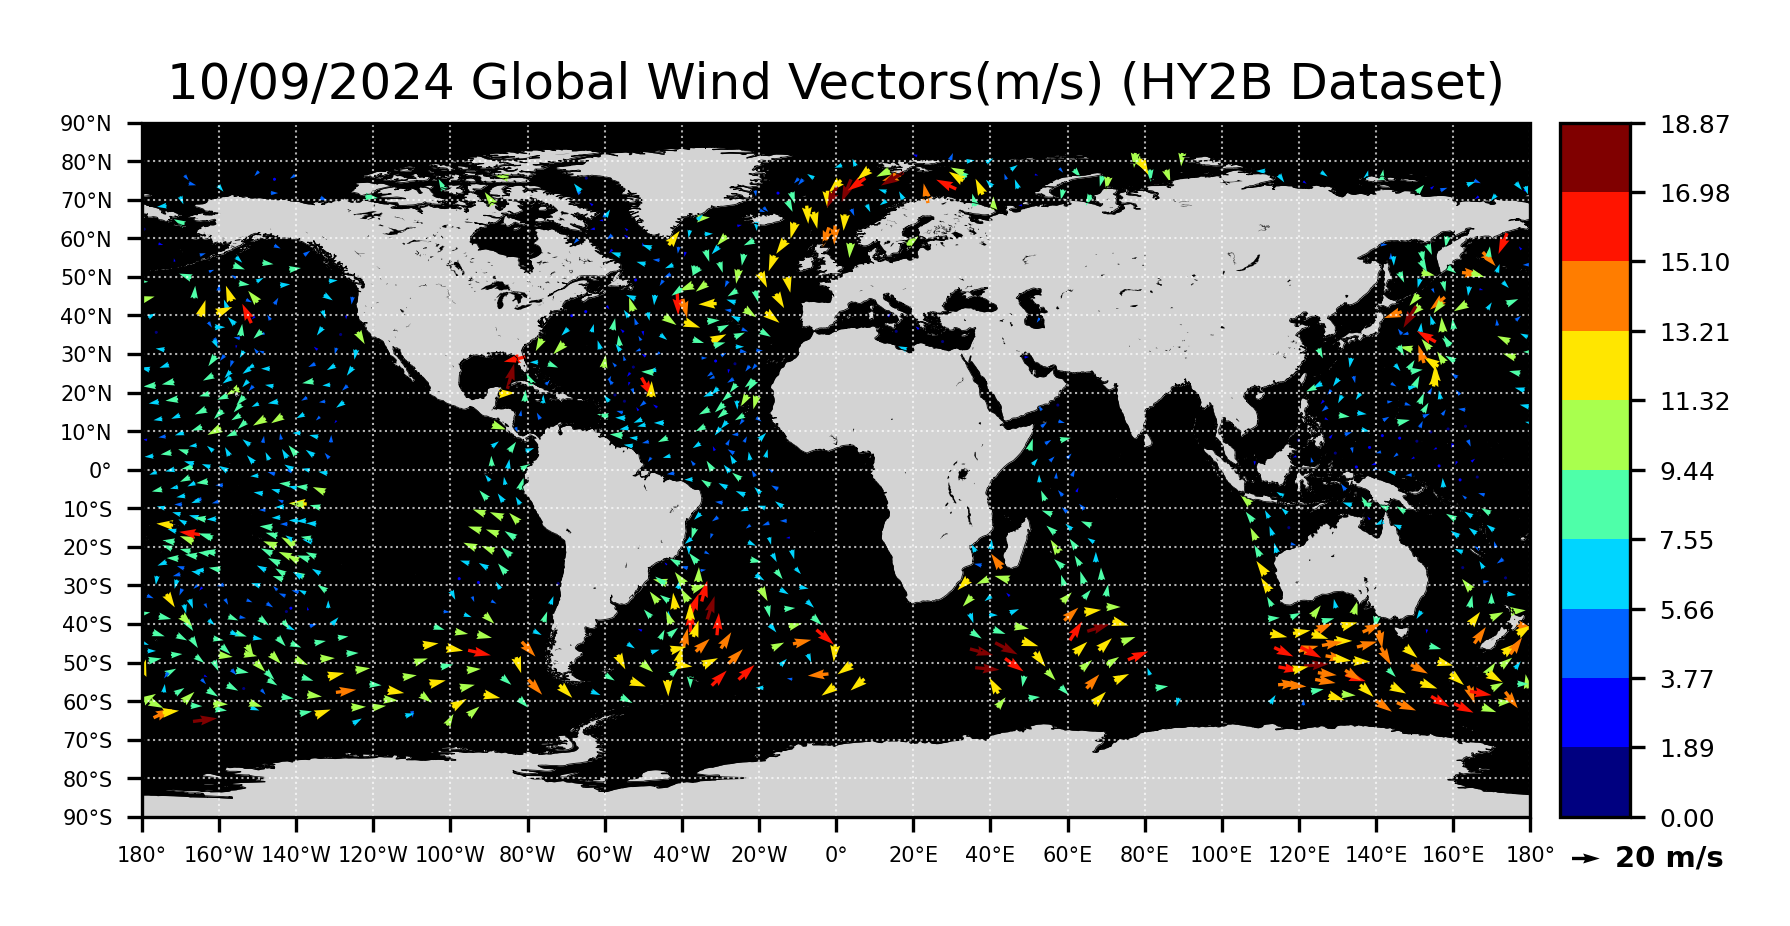

In [95]:
run_plot(
    file_name="HY2B_nc/HY2B_20241009.nc",
    plot_type="vectors",
    imgname=os.path.join(OUT_DIR, "HY2B_20241009_wind_vectors.png"),
    title="10/09/2024 Global Wind Vectors(m/s) (HY2B Dataset)",
    # n=4,
    # bound_box=(-100, -60, 10, 30),
    # bound_box=(-101.5, -89, 16.5, 28),
    # vmin=0,
    # vmax=20,
    # vector_size=600,  # smaller → longer arrows
)

notebook_plots/HY2B_20241009_wind_vectors_global.png created


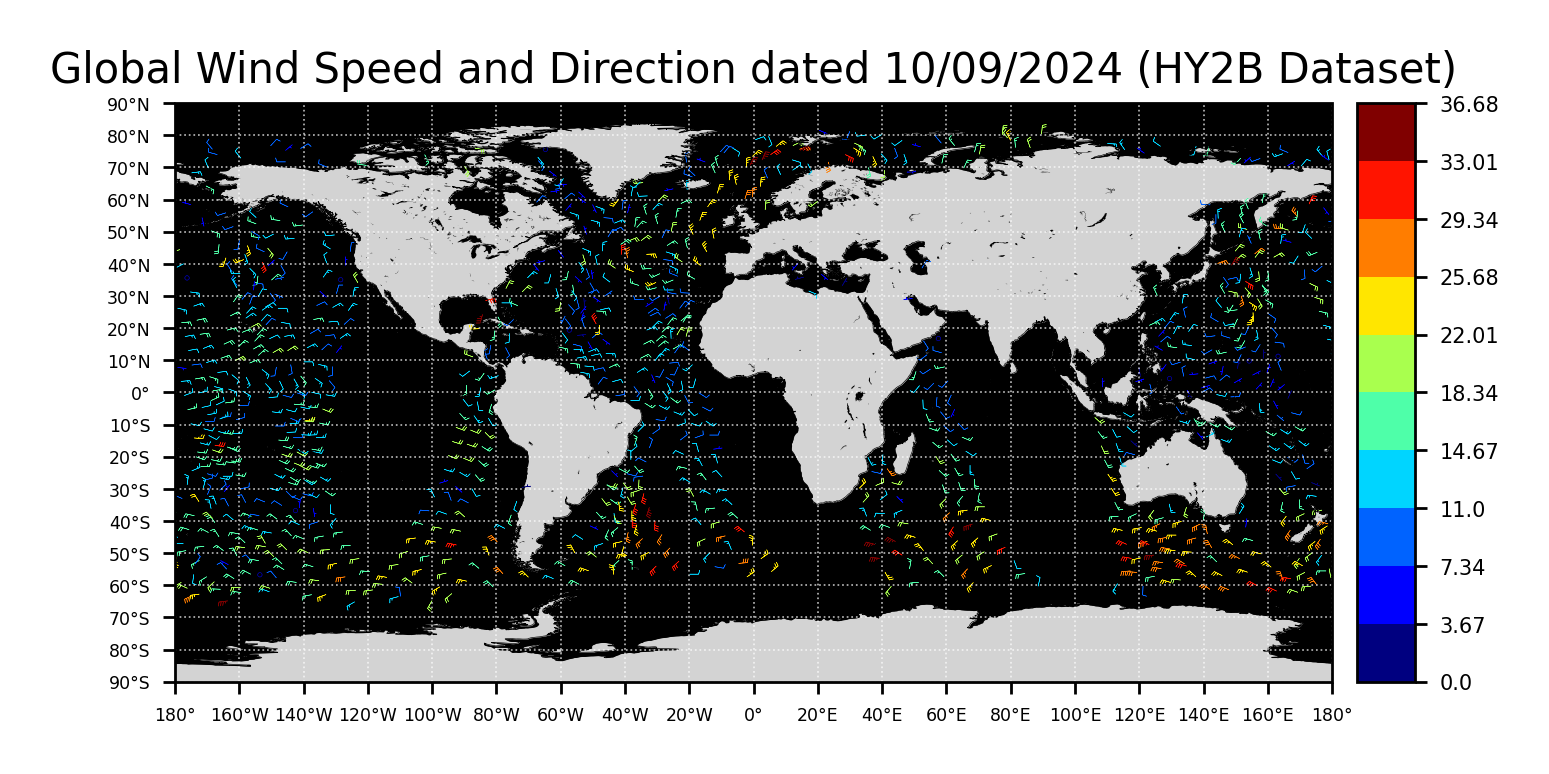

In [96]:
# Example: wind vectors (same as --vectors on the CLI)
run_plot(
    file_name="HY2B_nc/HY2B_20241009.nc",
    plot_type="barbs",
    imgname=os.path.join(OUT_DIR, "HY2B_20241009_wind_vectors_global.png"),
    title="Global Wind Speed and Direction dated 10/09/2024 (HY2B Dataset)",
    # n=20,
    # bound_box=(-100, -60, 10, 30),
    # vmin=0,
    # vmax=20,
    # vector_size=600,  # smaller → longer arrows
)


notebook_plots/HY2B_20241009.png created


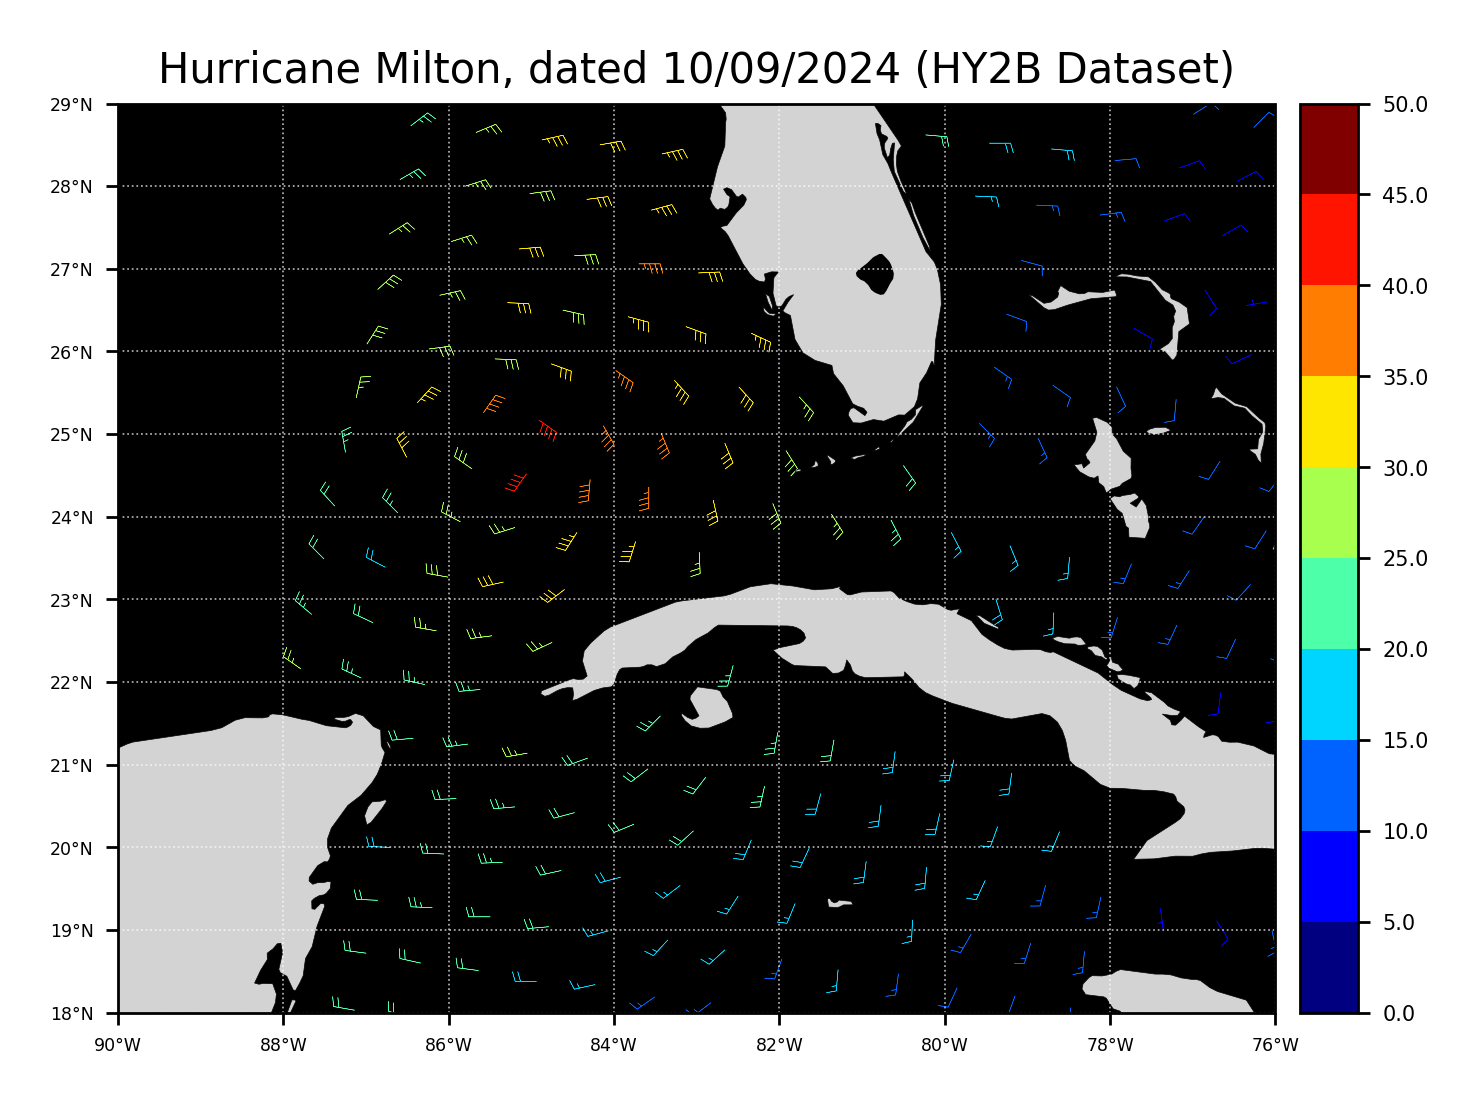

In [97]:
run_plot(
    file_name="HY2B_nc/HY2B_20241009.nc",
    plot_type="barbs",
    imgname=os.path.join(OUT_DIR, "HY2B_20241009.png"),
    title="Hurricane Milton, dated 10/09/2024 (HY2B Dataset)",
    n=3,
    #bound_box=(-98, -80, 18, 31), 
    # bound_box=(-100, -80, 17, 31),
    bound_box=(-90, -76, 18, 29),
    vmin=0,
    vmax=50,
    barb_size=3.5,
)


notebook_plots/ASCATB_25_2024277.png created


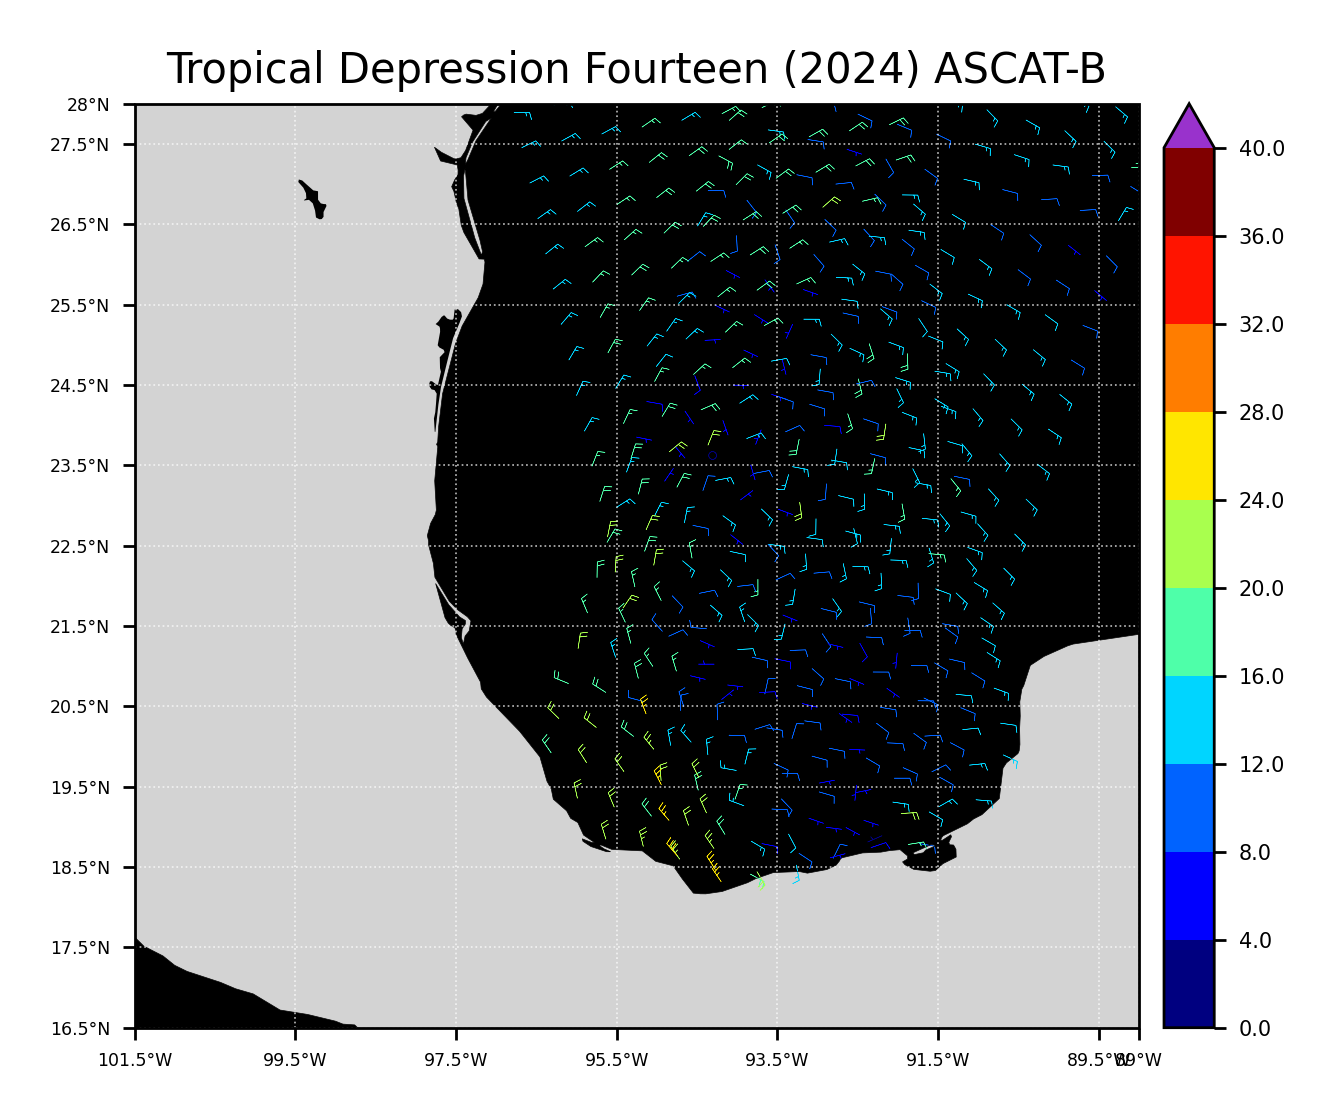

In [98]:
# Barbs (vmin/vmax in knots)
run_plot(
    file_name="ASCATB_25_nc/ASCATB_coast_2024277.nc",
    plot_type="barbs",
    imgname=os.path.join(OUT_DIR, "ASCATB_25_2024277.png"),
    title="Tropical Depression Fourteen (2024) ASCAT-B",
    n=4,                              
    bound_box=(-101.5, -89, 16.5, 28),
    vmin=0,
    vmax=40,                         
    barb_size=3.0,               
)

notebook_plots/OSCAT3_20241030.png created


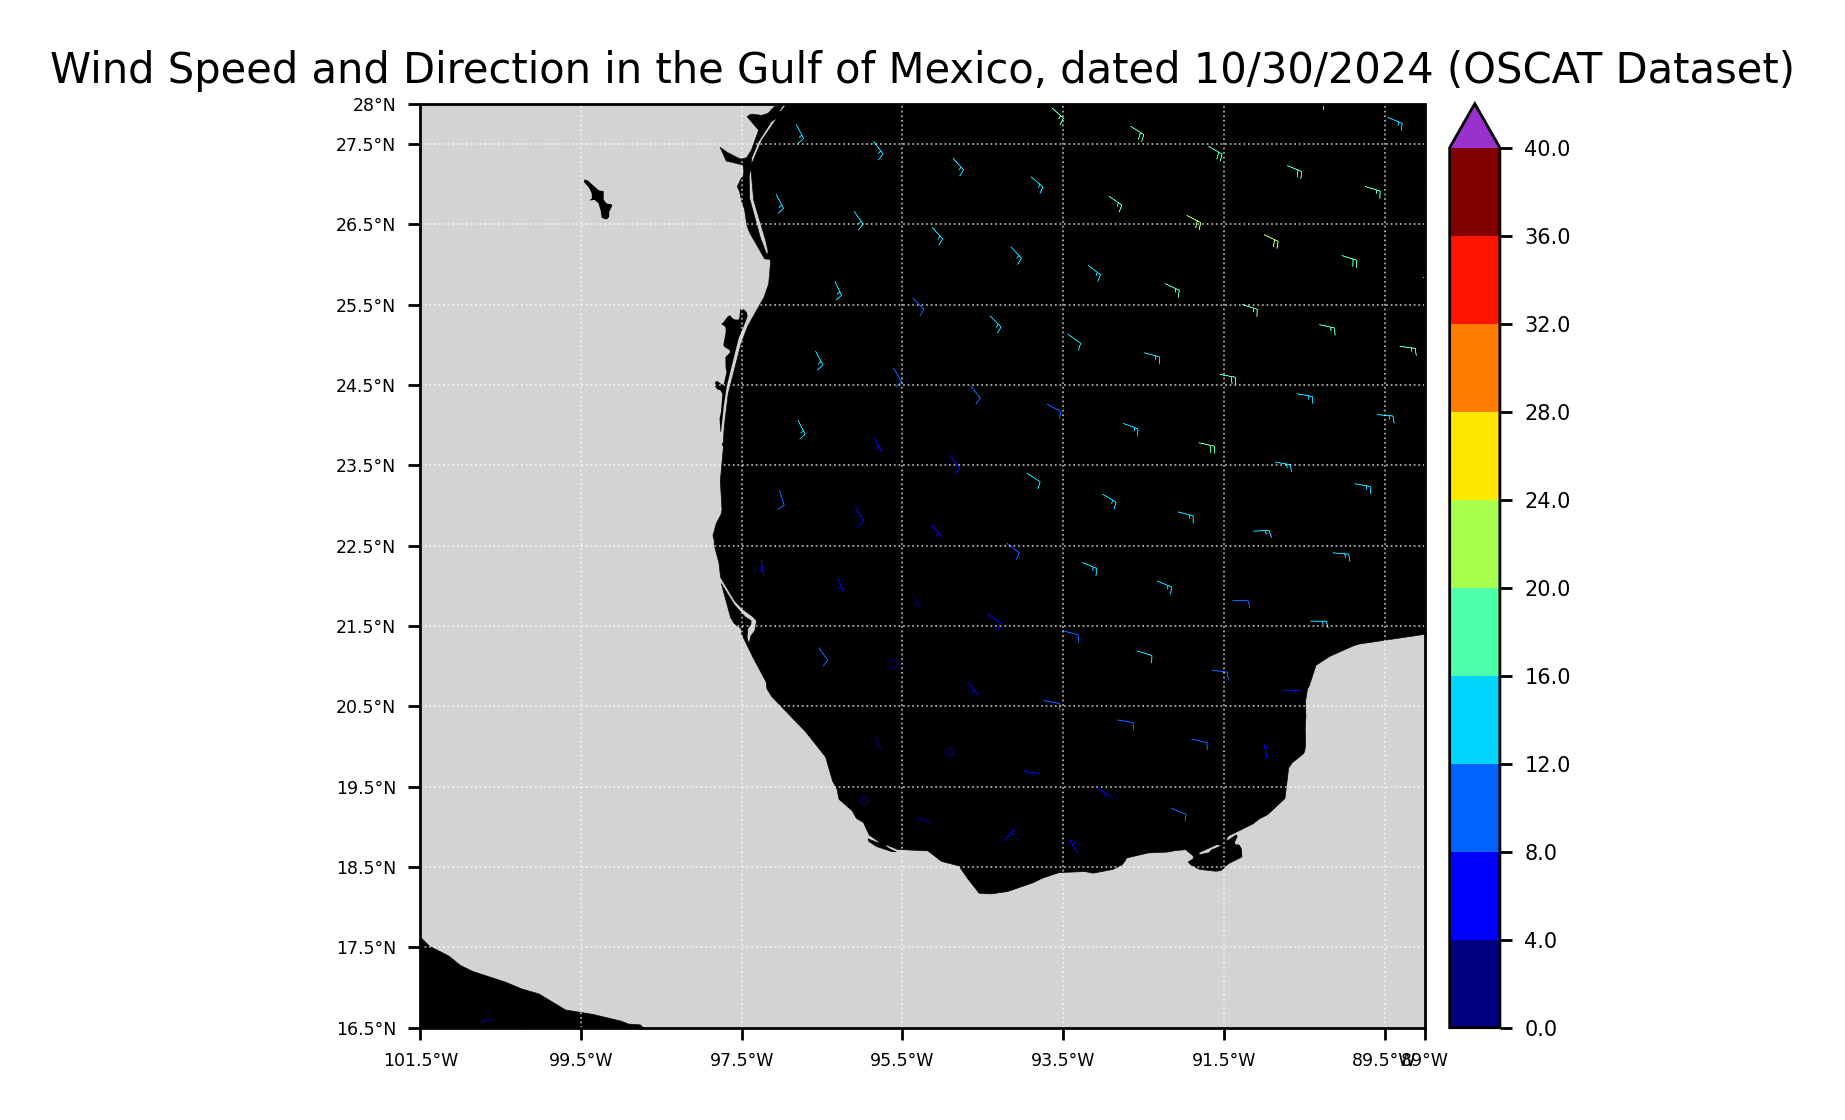

In [99]:
# Barbs (vmin/vmax in knots)
run_plot(
    file_name="OSCAT_nc/OSCAT3_20241030.nc",
    plot_type="barbs",
    imgname=os.path.join(OUT_DIR, "OSCAT3_20241030.png"),
    title="Wind Speed and Direction in the Gulf of Mexico, dated 10/30/2024 (OSCAT Dataset)",
    n=4,                              
    bound_box=(-101.5, -89, 16.5, 28),
    vmin=0,
    vmax=40,                         
    barb_size=3.0,               
)

## Other plot-type snippets

```python
# Speed
run_plot(plot_type="speed", imgname=os.path.join(OUT_DIR, "demo_speed.png"),
         title="Wind Speed (m/s)", n=25, bound_box=(-100, -60, 10, 30),
         vmin=0, vmax=20)

# Barbs (vmin/vmax in knots)
run_plot(plot_type="barbs", imgname=os.path.join(OUT_DIR, "demo_barbs.png"),
         title="Wind Barbs (knots)", n=18, bound_box=(-100, -60, 10, 30),
         vmin=0, vmax=40, barb_size=3.0)

# Flags
run_plot(plot_type="flags", imgname=os.path.join(OUT_DIR, "demo_flags.png"),
         title="Quality Flag", n=20, bound_box=(-100, -60, 10, 30))

# Param (reload with the variable name)
_, _, _, _, _, _, model_speed = read_file(FILENAME, param_name="model_speed")
run_plot(plot_type="param", imgname=os.path.join(OUT_DIR, "demo_param.png"),
         title="model_speed", n=25, bound_box=(-100, -60, 10, 30),
         vmin=0, vmax=20, param=model_speed)
```
